# **CS 483 – Big Data Mining: FairLend Miners**
## **Task: FP-Growth Association Rule Mining**

**Author:** Dhwani Chande

**Dataset:** HMDA 2023 | Chicago-Naperville-Elgin MSA | 103,481 loans

**Goal:** Mine association rules from mortgage lending data under standard vs. fair (ε-biased) binning to detect and compare racial bias patterns in loan denial.

---
### Notebook Structure
0. Suppress Warnings
1. Install Libraries & Imports
2. Load Data
3. Exploratory Data Analysis (EDA)
4. Build Transactions + FP-Growth
5. Association Rules + Denial Analysis
6. Visualizations
7. Export Results

## **0. Suppress Warnings**
Suppresses Jupyter kernel deprecation warnings to keep output clean.

In [ ]:
import sys, logging, warnings
warnings.filterwarnings('ignore')
logging.disable(logging.WARNING)

class _NoWarn:
    def write(self, msg):
        if 'DeprecationWarning' not in msg and 'utcnow' not in msg:
            sys.__stderr__.write(msg)
    def flush(self):
        sys.__stderr__.flush()
sys.stderr = _NoWarn()

print('Warnings suppressed')

Warnings suppressed


## **1. Install Libraries & Imports**

- **mlxtend**: FP-Growth and association rule mining
- **pandas / numpy**: Data manipulation
- **matplotlib / seaborn**: Visualization

In [ ]:
!pip install mlxtend --quiet

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder

print('Libraries loaded')

Libraries loaded


## **2. Load Data**

We load three parquet files:

| File | Description | Used for |
|---|---|---|
| `hmda_chicago_2023_cleaned.parquet` | Raw numeric values | EDA |
| `hmda_chicago_2023_standard_binned.parquet` | Equal-frequency bins | FP-Growth (standard) |
| `hmda_chicago_2023_fair_binned.parquet` | ε-biased fair bins | FP-Growth (fair) |

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = '/content/drive/MyDrive/CS483_FairLend'

clean_df = pd.read_parquet(f'{PROJECT_DIR}/hmda_chicago_2023_cleaned.parquet')
std_df   = pd.read_parquet(f'{PROJECT_DIR}/hmda_chicago_2023_standard_binned.parquet')
fair_df  = pd.read_parquet(f'{PROJECT_DIR}/hmda_chicago_2023_fair_binned.parquet')

clean_df['denied_flag'] = (clean_df['denied'] == 1).astype(int)
std_df['denied_flag']   = (std_df['outcome'] == 'denied').astype(int)
fair_df['denied_flag']  = (fair_df['outcome'] == 'denied').astype(int)

total = len(clean_df)
print(f'Data loaded')
print(f'Total loans : {total:,}')
print(f'Originated  : {(clean_df["denied_flag"]==0).sum():,} ({(clean_df["denied_flag"]==0).sum()/total*100:.1f}%)')
print(f'Denied      : {(clean_df["denied_flag"]==1).sum():,} ({(clean_df["denied_flag"]==1).sum()/total*100:.1f}%)')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data loaded
Total loans : 103,481
Originated  : 78,760 (76.1%)
Denied      : 24,721 (23.9%)


## **3. Exploratory Data Analysis (EDA)**

Before mining rules, we examine raw denial patterns by race, income, and DTI to establish ground truth baselines.

**Key question:** Are certain demographic groups denied at disproportionately higher rates, even after controlling for financial factors?

In [ ]:
# Race
race = clean_df.groupby('derived_race').agg(
    count=('denied_flag','count'),
    denied=('denied_flag','sum'),
    avg_income=('income','mean')
)
race['pct_of_total'] = (race['count']/total*100).round(1)
race['denial_rate%'] = (race['denied']/race['count']*100).round(1)
race['avg_income_$K'] = race['avg_income'].round(0)

# Income quartile
clean_df['income_quartile'] = pd.qcut(
    clean_df['income'], q=4,
    labels=['Q1 Low','Q2 Mid-Low','Q3 Mid-High','Q4 High']
)
iq = clean_df.groupby('income_quartile', observed=True).agg(
    count=('denied_flag','count'),
    denied=('denied_flag','sum'),
    avg_income=('income','mean')
)
iq['denial_rate%']   = (iq['denied']/iq['count']*100).round(1)
iq['avg_income_$K']  = iq['avg_income'].round(0)

# DTI
clean_df['dti_range'] = pd.cut(
    clean_df['dti_numeric'],
    bins=[0,20,36,43,50,100],
    labels=['<20%','20-36%','36-43%','43-50%','>50%']
)
dti = clean_df.groupby('dti_range', observed=True).agg(
    count=('denied_flag','count'),
    denied=('denied_flag','sum'),
    avg_dti=('dti_numeric','mean')
)
dti['denial_rate%'] = (dti['denied']/dti['count']*100).round(1)
dti['avg_dti']      = dti['avg_dti'].round(1)

print('DENIAL RATE BY RACE')
print(race[['count','pct_of_total','denial_rate%','avg_income_$K']]
      .sort_values('denial_rate%', ascending=False).to_string())

print('\nDENIAL RATE BY INCOME QUARTILE')
print(iq[['count','denial_rate%','avg_income_$K']].to_string())

print('\nDENIAL RATE BY DTI RANGE')
print(dti[['count','denial_rate%','avg_dti']].to_string())

DENIAL RATE BY RACE
                                           count  pct_of_total  denial_rate%  avg_income_$K
derived_race                                                                               
2 or more minority races                     281           0.3          49.1          100.0
Native Hawaiian or Other Pacific Islander    171           0.2          45.6          107.0
American Indian or Alaska Native             691           0.7          40.8           92.0
Black or African American                  16171          15.6          38.6           99.0
Asian                                      10149           9.8          21.6          162.0
White                                      73799          71.3          20.9          139.0
Joint                                       2219           2.1          15.1          201.0

DENIAL RATE BY INCOME QUARTILE
                 count  denial_rate%  avg_income_$K
income_quartile                                    
Q1 Low          

## **4. Build Transactions + FP-Growth**

### Transaction Encoding
Each loan is represented as a set of items e.g. `{race=Black, income=Low, dti=High, outcome=denied}`. We encode each column value as a `column=value` string, then one-hot encode the full dataset.

### FP-Growth Parameters
| Parameter | Value | Rationale |
|---|---|---|
| `min_support` | 0.10 | Pattern must appear in ≥10% of loans (~10,348 cases) |
| `min_confidence` | 0.50 | Rule must be correct ≥50% of the time |
| `max_len` | 4 | Caps itemset size to prevent combinatorial explosion |

### Why Two Runs?
We run FP-Growth twice, once on standard equal-frequency bins and once on fair ε-biased bins to measure whether fairer binning changes the discovered denial patterns.

In [ ]:
def build_transactions(df, income_col, loan_col):
    item_cols = [
        'outcome','derived_race','derived_sex','derived_ethnicity',
        'applicant_age', income_col, loan_col,
        'dti_bin','loan_type_label','loan_purpose_label','occupancy_label'
    ]
    item_cols = [c for c in item_cols if c in df.columns]
    col_rename = {
        c: c.replace('derived_','').replace('_label','').replace('applicant_','')
        for c in item_cols
    }
    item_df = pd.DataFrame(index=df.index)
    for col in item_cols:
        short = col_rename[col]
        valid = df[col].notna() & (df[col].astype(str) != 'nan')
        item_df[col] = (short + '=' + df[col].astype(str)).where(valid, other=None)
    records = item_df.to_numpy()
    return [[cell for cell in row if cell is not None] for row in records]

def encode(transactions):
    te = TransactionEncoder()
    te_array = te.fit_transform(transactions)
    return pd.DataFrame(te_array, columns=te.columns_)

MIN_SUPPORT    = 0.10
MIN_CONFIDENCE = 0.50

print('Building transactions')
std_transactions  = build_transactions(std_df,  'income_bin_std',  'loan_amount_bin_std')
fair_transactions = build_transactions(fair_df, 'income_bin_fair', 'loan_amount_bin_fair')
std_encoded  = encode(std_transactions)
fair_encoded = encode(fair_transactions)
print(f'Standard : {len(std_transactions):,} transactions | {std_encoded.shape[1]} unique items')
print(f'Fair     : {len(fair_transactions):,} transactions | {fair_encoded.shape[1]} unique items')

print('\nRunning FP-Growth')
std_itemsets  = fpgrowth(std_encoded,  min_support=MIN_SUPPORT, use_colnames=True, max_len=4)
fair_itemsets = fpgrowth(fair_encoded, min_support=MIN_SUPPORT, use_colnames=True, max_len=4)
std_itemsets['length']  = std_itemsets['itemsets'].apply(len)
fair_itemsets['length'] = fair_itemsets['itemsets'].apply(len)
print(f'Standard itemsets : {len(std_itemsets):,}')
print(f'Fair itemsets     : {len(fair_itemsets):,}')

Building transactions
Standard : 103,481 transactions | 51 unique items
Fair     : 103,481 transactions | 51 unique items

Running FP-Growth
Standard itemsets : 819
Fair itemsets     : 854


## **5. Association Rules + Denial Analysis**

**Metrics:**
- **Support**: Fraction of all loans where the rule applies
- **Confidence**: Of loans matching antecedent, fraction that match consequent
- **Lift**: How much more likely the consequent is vs. by chance (lift > 1 = meaningful)

We filter for rules where `consequent = outcome=denied` and flag rules whose antecedents contain demographic attributes (race, sex, ethnicity) to directly surface bias.

In [ ]:
DENIAL_ITEM   = 'outcome=denied'
DEMO_KEYWORDS = ['race=','sex=','ethnicity=']

print('Generating association rules')
std_rules  = association_rules(std_itemsets,  metric='confidence', min_threshold=MIN_CONFIDENCE)
fair_rules = association_rules(fair_itemsets, metric='confidence', min_threshold=MIN_CONFIDENCE)
std_rules  = std_rules[std_rules['lift']  >= 1.0]
fair_rules = fair_rules[fair_rules['lift'] >= 1.0]

def filter_denial(rules):
    return rules[rules['consequents'].apply(lambda x: DENIAL_ITEM in x)].copy()

def flag_demo(rules):
    rules = rules.copy()
    rules['has_demographic'] = rules['antecedents'].apply(
        lambda x: any(any(kw in item for kw in DEMO_KEYWORDS) for item in x))
    return rules

std_denial  = flag_demo(filter_denial(std_rules))
fair_denial = flag_demo(filter_denial(fair_rules))
std_demo    = std_denial[std_denial['has_demographic']]
fair_demo   = fair_denial[fair_denial['has_demographic']]

cols = ['antecedents','consequents','support','confidence','lift']

print('\nCOMPARISON SUMMARY')
print(f'{"Metric":<40} {"Standard":>10} {"Fair":>10}')

print(f'{"Frequent itemsets":<40} {len(std_itemsets):>10,} {len(fair_itemsets):>10,}')
print(f'{"Association rules":<40} {len(std_rules):>10,} {len(fair_rules):>10,}')
print(f'{"Denial rules":<40} {len(std_denial):>10,} {len(fair_denial):>10,}')
print(f'{"Demographic denial rules":<40} {len(std_demo):>10,} {len(fair_demo):>10,}')
print(f'{"Avg confidence":<40} {std_rules["confidence"].mean():>10.3f} {fair_rules["confidence"].mean():>10.3f}')
print(f'{"Avg lift":<40} {std_rules["lift"].mean():>10.3f} {fair_rules["lift"].mean():>10.3f}')

print('\nTop 5 denial rules (STANDARD):')
print(std_denial.sort_values('confidence', ascending=False)[cols].head(5).to_string(index=False))
print('\nTop 5 denial rules (FAIR):')
print(fair_denial.sort_values('confidence', ascending=False)[cols].head(5).to_string(index=False))

Generating association rules

COMPARISON SUMMARY
Metric                                     Standard       Fair
Frequent itemsets                               819        854
Association rules                             2,214      2,454
Denial rules                                      3          3
Demographic denial rules                          0          0
Avg confidence                                0.754      0.738
Avg lift                                      1.140      1.208

Top 5 denial rules (STANDARD):
                             antecedents                            consequents  support  confidence     lift
                      (dti_bin=DTI_High)                       (outcome=denied) 0.107053    0.672005 2.812982
(occupancy=PrimaryRes, dti_bin=DTI_High)                       (outcome=denied) 0.101545    0.663091 2.775668
                      (dti_bin=DTI_High) (outcome=denied, occupancy=PrimaryRes) 0.101545    0.637428 2.822011

Top 5 denial rules (FAIR):
          

## **6. Visualizations**

Three plots summarizing our findings:
1. **Denial rate by race** — ground truth demographic disparity from raw data
2. **Denial rate by income quartile** — financial factor impact on denial
3. **Standard vs Fair binning** — comparison of FP-Growth results

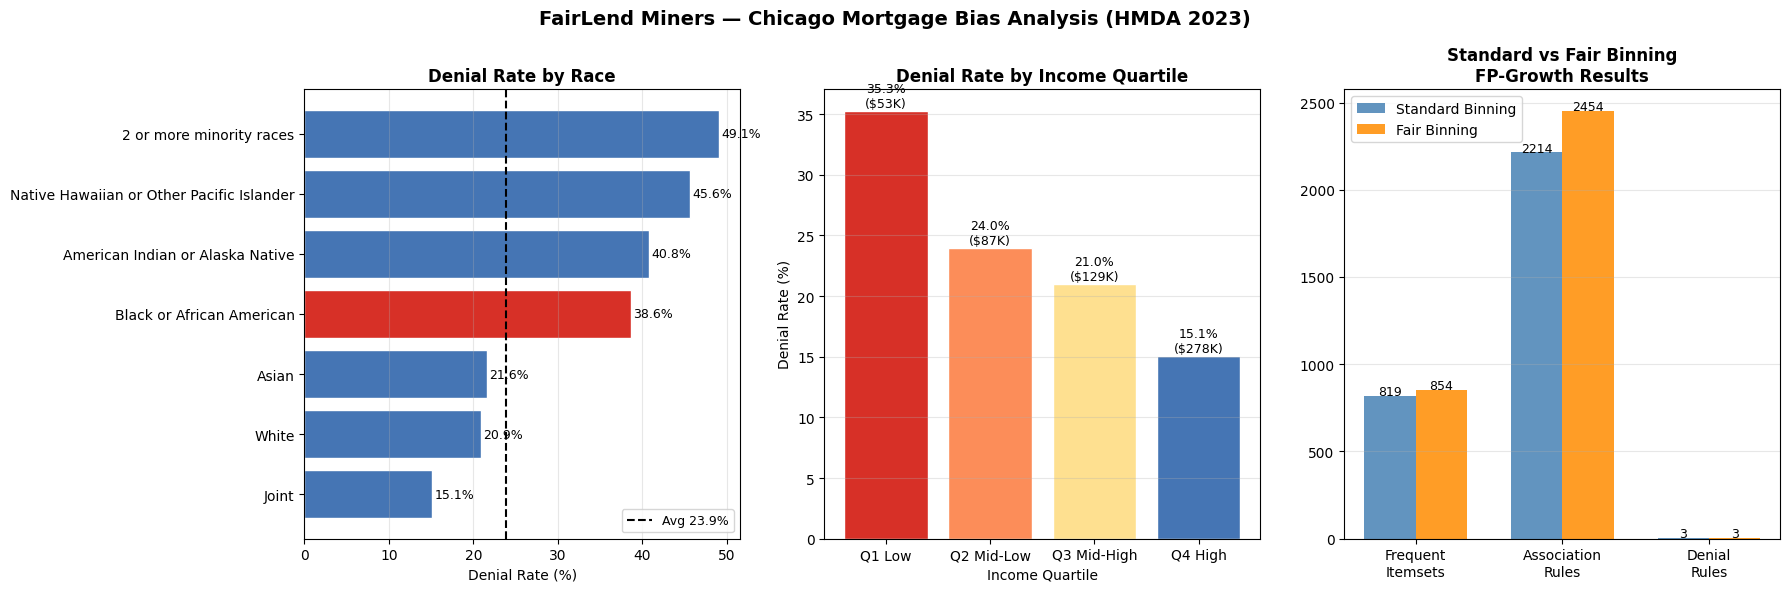

Plot saved: memberB_analysis.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('FairLend Miners — Chicago Mortgage Bias Analysis (HMDA 2023)',
             fontsize=14, fontweight='bold')

# Plot 1: Denial rate by race
race_plot = race[['denial_rate%']].sort_values('denial_rate%', ascending=True)
colors = ['#d73027' if 'Black' in str(r) else '#4575b4' for r in race_plot.index]
axes[0].barh(race_plot.index, race_plot['denial_rate%'], color=colors, edgecolor='white')
axes[0].axvline(clean_df['denied_flag'].mean()*100, color='black',
                linestyle='--', linewidth=1.5,
                label=f'Avg {clean_df["denied_flag"].mean()*100:.1f}%')
axes[0].set_xlabel('Denial Rate (%)')
axes[0].set_title('Denial Rate by Race', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(axis='x', alpha=0.3)
for i, (idx, row) in enumerate(race_plot.iterrows()):
    axes[0].text(row['denial_rate%']+0.3, i, f"{row['denial_rate%']}%", va='center', fontsize=9)

# Plot 2: Denial rate by income quartile
bars = axes[1].bar(iq.index, iq['denial_rate%'],
                   color=['#d73027','#fc8d59','#fee090','#4575b4'], edgecolor='white')
axes[1].set_xlabel('Income Quartile')
axes[1].set_ylabel('Denial Rate (%)')
axes[1].set_title('Denial Rate by Income Quartile', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
for bar, (idx, row) in zip(bars, iq.iterrows()):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f"{row['denial_rate%']}%\n(${int(row['avg_income_$K'])}K)",
                 ha='center', fontsize=9)

# Plot 3: Standard vs Fair FP-Growth comparison
categories = ['Frequent\nItemsets', 'Association\nRules', 'Denial\nRules']
std_vals  = [len(std_itemsets),  len(std_rules),  len(std_denial)]
fair_vals = [len(fair_itemsets), len(fair_rules), len(fair_denial)]
x = np.arange(len(categories))
w = 0.35
axes[2].bar(x-w/2, std_vals,  w, label='Standard Binning', color='steelblue',  alpha=0.85)
axes[2].bar(x+w/2, fair_vals, w, label='Fair Binning',     color='darkorange', alpha=0.85)
axes[2].set_xticks(x)
axes[2].set_xticklabels(categories)
axes[2].set_title('Standard vs Fair Binning\nFP-Growth Results', fontweight='bold')
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)
for i, (sv, fv) in enumerate(zip(std_vals, fair_vals)):
    axes[2].text(i-w/2, sv+5, str(sv), ha='center', fontsize=9)
    axes[2].text(i+w/2, fv+5, str(fv), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/memberB_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved: memberB_analysis.png')

## **7. Export Results**

Saving all association rules and denial-specific rules as CSV files to Google Drive for use in the final report.

In [ ]:
def rules_to_csv(rules_df, path):
    out = rules_df.copy()
    out['antecedents'] = out['antecedents'].apply(lambda x: ', '.join(sorted(x)))
    out['consequents'] = out['consequents'].apply(lambda x: ', '.join(sorted(x)))
    out.to_csv(path, index=False)
    print(f'  Saved {len(out):,} rules → {path}')

rules_to_csv(std_rules,  f'{PROJECT_DIR}/memberB_std_rules.csv')
rules_to_csv(fair_rules, f'{PROJECT_DIR}/memberB_fair_rules.csv')
rules_to_csv(std_denial, f'{PROJECT_DIR}/memberB_std_denial_rules.csv')
rules_to_csv(fair_denial,f'{PROJECT_DIR}/memberB_fair_denial_rules.csv')

  Saved 2,214 rules → /content/drive/MyDrive/CS483_FairLend/memberB_std_rules.csv
  Saved 2,454 rules → /content/drive/MyDrive/CS483_FairLend/memberB_fair_rules.csv
  Saved 3 rules → /content/drive/MyDrive/CS483_FairLend/memberB_std_denial_rules.csv
  Saved 3 rules → /content/drive/MyDrive/CS483_FairLend/memberB_fair_denial_rules.csv
